# A route as an object

What planning gives you now, and what it looks like in a notebook.

In [1]:
from synplan.utils.loading import (
    download_preset,
    load_building_blocks,
    load_evaluation_function,
    load_policy_function,
    load_reaction_rules,
)

paths = download_preset("synplanner-gps", save_to="synplan_data")
building_blocks = load_building_blocks(paths["building_blocks"], standardize=True, silent=True)
reaction_rules = load_reaction_rules(paths["reaction_rules"])
policy_function = load_policy_function(weights_path=paths["ranking_policy"])

In [2]:
from synplan.chem.utils import mol_from_smiles
from synplan.mcts.tree import Tree
from synplan.utils.config import RolloutEvaluationConfig, TreeConfig

tree_config = TreeConfig(
    search_strategy="expansion_first",
    max_iterations=200,
    max_time=90,
    max_depth=9,
    min_mol_size=1,
    init_node_value=0.5,
    ucb_type="uct",
    c_ucb=0.1,
)

evaluation_function = load_evaluation_function(
    RolloutEvaluationConfig(
        policy_network=policy_function,
        reaction_rules=reaction_rules,
        building_blocks=building_blocks,
        min_mol_size=tree_config.min_mol_size,
        max_depth=tree_config.max_depth,
    )
)

# capivasertib, an anti-cancer drug approved in 2023
target = mol_from_smiles(
    "NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]c3nccc2-3)CC1",
    clean2d=True,
    standardize=True,
    clean_stereo=True,
)

tree = Tree(
    target=target,
    config=tree_config,
    reaction_rules=reaction_rules,
    building_blocks=building_blocks,
    expansion_function=policy_function,
    evaluation_function=evaluation_function,
)
for _solved, _node_id in tree:
    pass
tree

  0%|          | 0/200 [00:00<?, ?it/s]

Tree for: c1cc(ccc1Cl)C(NC(C2(CCN(CC2)c3c4cc[nH]c4ncn3)N)=O)CCO
Time: 17.5 seconds
Number of nodes: 5426
Number of iterations: 200
Number of visited nodes: 200
Number of found routes: 118

## The routes

`tree.routes()` hands back objects, best first. A route draws itself, so the last line of a cell is the whole incantation:

```python
# before
from IPython.display import SVG, display
from synplan.utils.visualisation import get_route_svg

display(SVG(get_route_svg(tree, tree.winning_nodes[0])))
```

118 solved routes


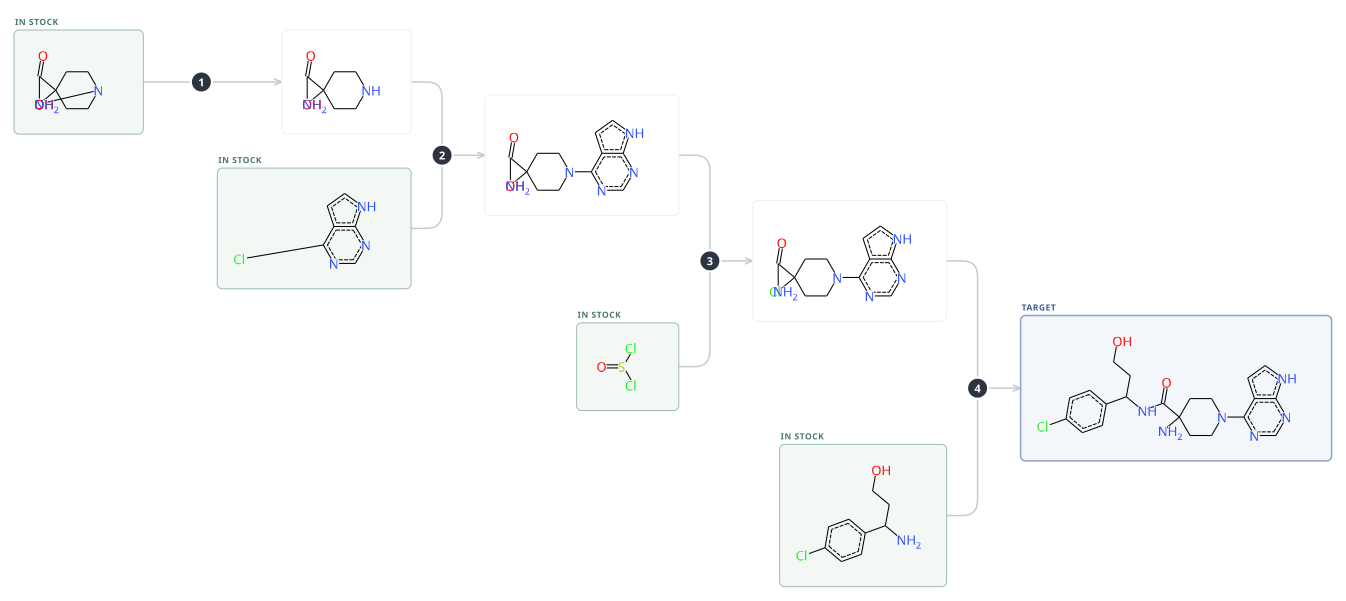

In [3]:
routes = tree.routes()
print(f'{len(routes)} solved routes')
routes[0]

## Reading one

Steps come out in the order they are run: step 1 first, the cut from the target last.

In [4]:
route = routes[0]

for number, step in enumerate(route, 1):
    rule = step.origin.rule_key if step.origin else None
    print(f'{number}. {step.reaction}')
    print(f'   makes {step.product}   rule {rule}')

1. CC(C)(C)OC(=O)N1CCC(CC1)(C(O)=O)N>>C1CC(CCN1)(C(O)=O)N
   makes C1CC(CCN1)(C(O)=O)N   rule policy:3
2. C1CC(CCN1)(C(O)=O)N.[nH]1c2c(c(ncn2)Cl)cc1>>C1CC(CCN1c2c3cc[nH]c3ncn2)(N)C(=O)O
   makes C1CC(CCN1c2c3cc[nH]c3ncn2)(N)C(=O)O   rule policy:14
3. C1CC(CCN1c2c3cc[nH]c3ncn2)(N)C(=O)O.ClS(Cl)=O>>C1CC(CCN1c2c3cc[nH]c3ncn2)(N)C(Cl)=O
   makes C1CC(CCN1c2c3cc[nH]c3ncn2)(N)C(Cl)=O   rule policy:163
4. C1CC(CCN1c2c3cc[nH]c3ncn2)(N)C(Cl)=O.c1cc(ccc1Cl)C(CCO)N>>c1cc(ccc1Cl)C(NC(C2(CCN(CC2)c3c4cc[nH]c4ncn3)N)=O)CCO
   makes c1cc(ccc1Cl)C(NC(C2(CCN(CC2)c3c4cc[nH]c4ncn3)N)=O)CCO   rule policy:32


## What it knows about itself

In [5]:
print('target      ', route.target)
print('steps       ', len(route))
print('solved      ', route.solved)
print('unresolved  ', sorted(route.unresolved) or 'none')
print('score       ', route.provenance.search_score)
print()
for mol in (route.target, *route.leaves()):
    print(f'{route.position(mol):<13}{mol}')

target       c1cc(ccc1Cl)C(NC(C2(CCN(CC2)c3c4cc[nH]c4ncn3)N)=O)CCO
steps        4
solved       True
unresolved   none
score        0.1434644689007252

target       c1cc(ccc1Cl)C(NC(C2(CCN(CC2)c3c4cc[nH]c4ncn3)N)=O)CCO
leaf         CC(C)(C)OC(=O)N1CCC(CC1)(C(O)=O)N
leaf         [nH]1c2c(c(ncn2)Cl)cc1
leaf         ClS(Cl)=O
leaf         c1cc(ccc1Cl)C(CCO)N


## It outlives the search

No catalogue, no tree, no search graph — so it pickles small and travels between processes.

In [ ]:
import pickle

blob = pickle.dumps(route)
print(f'pickled route: {len(blob):,} B for {len(route)} steps')
print(f'the tree it came from: {len(pickle.dumps(tree.building_blocks)):,} B of catalogue alone')

restored = pickle.loads(blob)
print(f'round trip: {len(restored)} steps, target {restored.target}, solved {restored.solved}')

## And through JSON

In [ ]:
from synplan.chem.reaction.routes.route import Route

as_json = route.to_json()
back = Route.from_json(as_json)

print('target survives  ', str(back.target) == str(route.target))
print('steps survive    ', len(back) == len(route))
print('verdict survives ', back.solved == route.solved)
back

## A few at once

4 steps, score 0.143


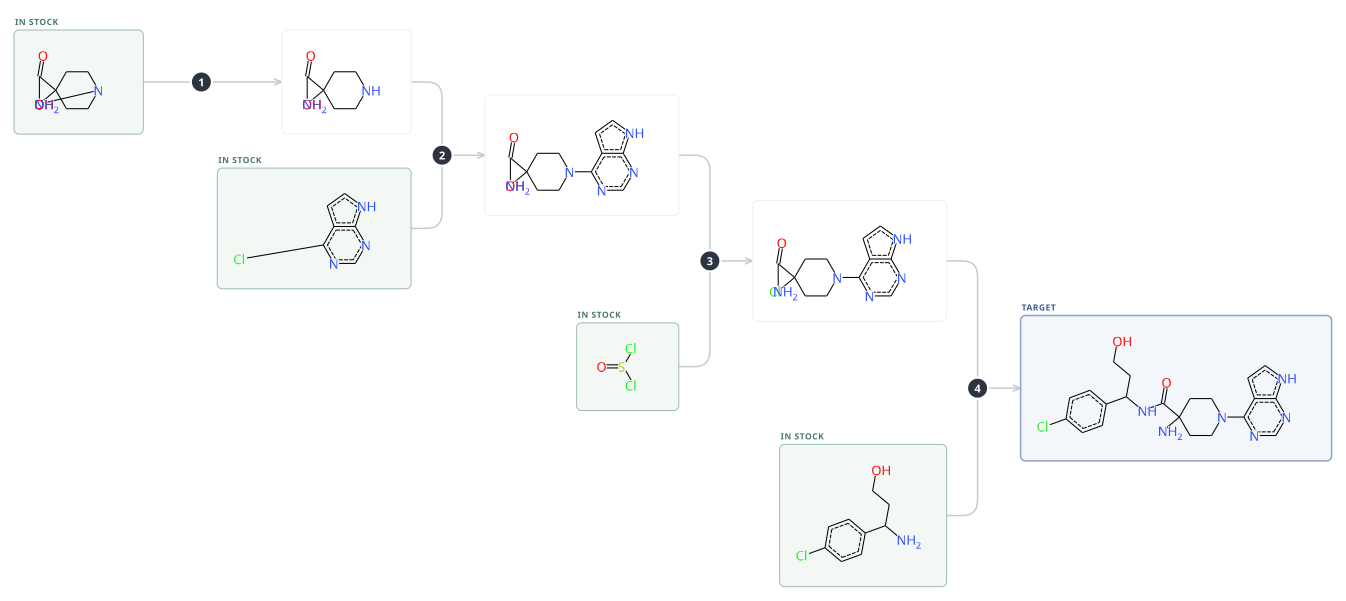

4 steps, score 0.143


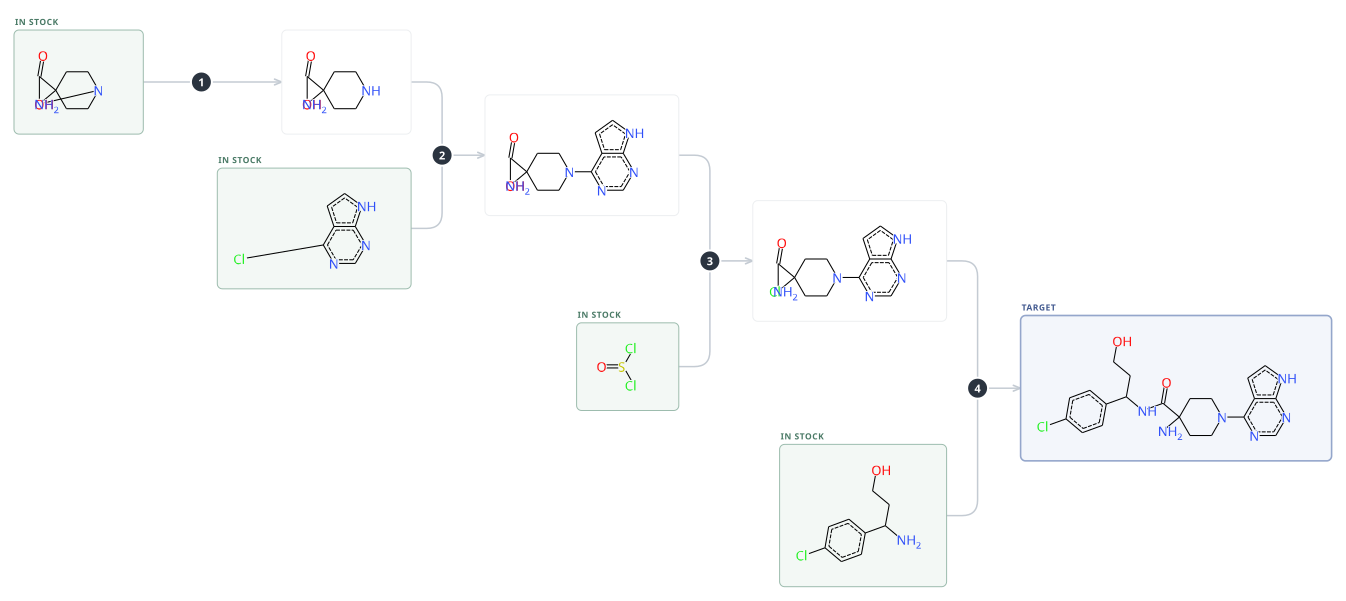

4 steps, score 0.143


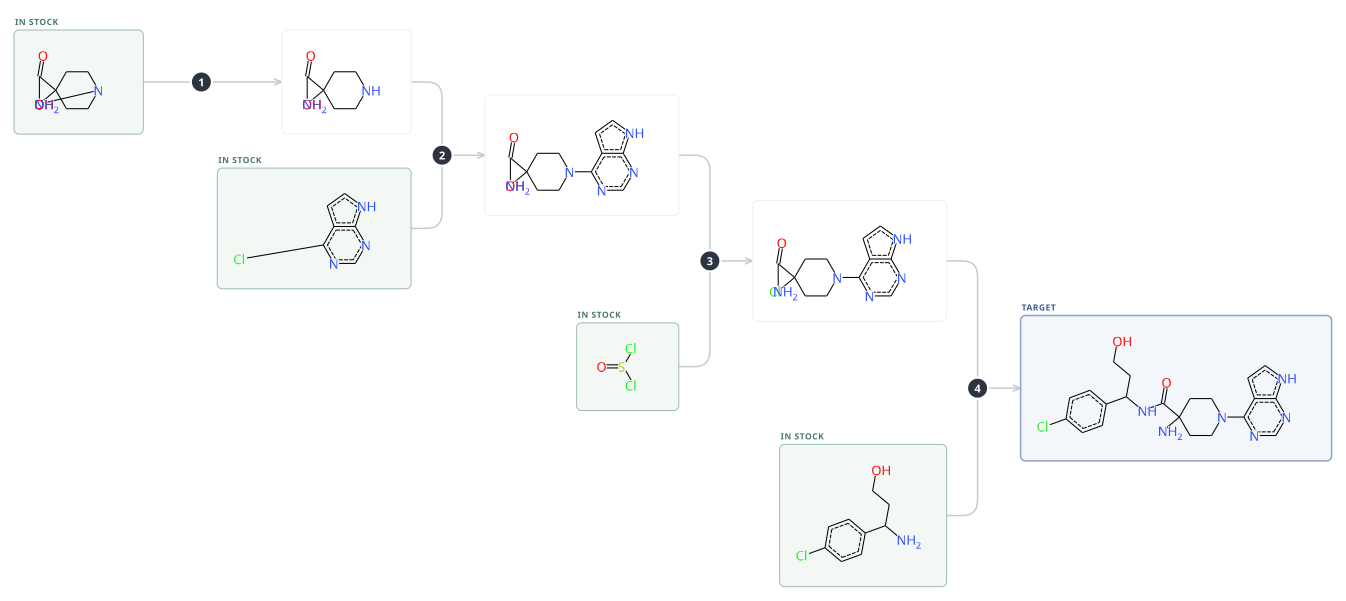

In [6]:
from IPython.display import display

for r in routes[:3]:
    print(f'{len(r)} steps, score {r.provenance.search_score:.3f}')
    display(r)